# 05 · Experimento V3 · Validación cruzada temporal interna

Proyecto: **Clasificación anticipada de amenaza meteorológica por lluvias intensas**.

Objetivo del notebook: comparar, bajo las mismas particiones temporales y características, los cinco modelos definidos en la Tarea #4:

1. Random Forest
2. Regresión Logística Multinomial
3. XGBoost
4. SVM con kernel RBF
5. MLP

Además se incluye un `DummyClassifier` únicamente como baseline de referencia.

**Regla metodológica:** el conjunto de prueba temporal y el holdout espacial no se utilizan para ajustar hiperparámetros ni para elegir el modelo ganador.

## 0. Dependencias

In [1]:
# Ejecutar una sola vez si alguna dependencia no está instalada.
# En Colab suele bastar con ejecutar esta celda.
%pip install -q scikit-learn xgboost joblib matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importaciones y configuración

In [2]:
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
    recall_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Entorno listo.")

Entorno listo.


## 2. Ruta del proyecto

El notebook intenta detectar automáticamente la carpeta del proyecto. Si no la encuentra, cambia `PROJECT_DIR` manualmente.

In [3]:
candidates = [
    Path.cwd(),
    Path.cwd() / "rain-threat-classifier",
    Path("/content/rain-threat-classifier"),
    Path("/content/drive/MyDrive/rain-threat-classifier"),
]

PROJECT_DIR = next(
    (p for p in candidates if (p / "resultados_completo" / "dataset_modelo_mensual_v3.csv").exists()),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "No se encontró el proyecto. Define PROJECT_DIR con la ruta de rain-threat-classifier."
    )

DATA_DIR = PROJECT_DIR / "resultados_completo"
EXPERIMENT_NAME = "v3_temporal_167_cv"
OUTPUT_DIR = PROJECT_DIR / "resultados_experimentos" / EXPERIMENT_NAME
ARTIFACT_DIR = PROJECT_DIR / "artefactos_experimentos" / EXPERIMENT_NAME

for folder in [OUTPUT_DIR, ARTIFACT_DIR, OUTPUT_DIR / "matrices_confusion", OUTPUT_DIR / "predicciones"]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier


## 3. Carga del dataset V3 y sus características

In [4]:
DATASET_PATH = DATA_DIR / "dataset_modelo_mensual_v3.csv"
FEATURES_PATH = DATA_DIR / "columnas_modelo_v3.txt"

df = pd.read_csv(DATASET_PATH)
df["period_start"] = pd.to_datetime(df["period_start"])
df["target_period_start"] = pd.to_datetime(df["target_period_start"])

features = [
    line.strip()
    for line in FEATURES_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

print("Dataset:", df.shape)
print("Características V3:", len(features))
print("Columnas faltantes:", sorted(set(features) - set(df.columns)))

Dataset: (6120, 209)
Características V3: 167
Columnas faltantes: []


In [5]:
# Auditoría específica de V3
V3_EXPECTED_NEW = [
    "prcptot_mm_lag11",
    "rx1day_mm_lag11",
    "rx5day_mm_lag11",
    "max_6h_mm_lag11",
    "wet_days_lag11",
    "sdii_mm_per_wet_day_lag11",
    "temperature_mean_c_lag11",
    "relative_humidity_mean_pct_lag11",
    "prcptot_media_3m",
    "prcptot_media_6m",
    "rx5_media_3m",
    "rx5_max_6m",
    "humedad_media_3m",
    "temperatura_media_3m",
    "prcptot_tendencia_1m",
    "rx5_tendencia_1m",
    "humedad_tendencia_1m",
    "temperatura_tendencia_1m",
]

assert set(V3_EXPECTED_NEW).issubset(df.columns)
assert "target_amenaza" not in features
assert "target_rx5day_mm" not in features
assert df[features].isna().sum().sum() == 0

print("V3 validada. Nuevas características temporales:", len(V3_EXPECTED_NEW))


V3 validada. Nuevas características temporales: 18


## 4. Auditoría rápida antes de entrenar

In [6]:
assert df.shape[0] == 6120, f"Se esperaban 6120 filas en V3 y llegaron {len(df)}"
assert len(features) == 167, f"Se esperaban 167 características V3 y llegaron {len(features)}"
assert set(features).issubset(df.columns)
assert df[features].isna().sum().sum() == 0, "Hay nulos en las características V3."
assert df["target_amenaza"].isna().sum() == 0, "Hay targets nulos."
assert set(df["target_amenaza"].unique()) == {"Baja", "Media", "Alta"}

print("Distribución por partición (solo para auditoría de conteos):")
display(df["split"].value_counts().rename("filas").to_frame())

print("IMPORTANTE: para decidir si V3 sirve, a partir de aquí se usa SOLO split=entrenamiento.")


Distribución por partición (solo para auditoría de conteos):


,filas
split,
entrenamiento,3744
holdout_historia,936
validacion_temporal,576
prueba_temporal,576
holdout_espacial,288


IMPORTANTE: para decidir si V3 sirve, a partir de aquí se usa SOLO split=entrenamiento.


## 5. Aislar exclusivamente el conjunto de entrenamiento

- `entrenamiento`: 12 zonas, objetivos hasta 2017. Se usa para aprender y ajustar hiperparámetros.
- `validacion_temporal`: 2018–2021. Se usa para comparar los cinco modelos ya ajustados.
- `prueba_temporal`: 2022–2025. Se reserva para la evaluación final.
- `holdout_espacial`: Santo Domingo, Nueva Loja y Macas en 2018–2025. Se reserva para evaluar generalización geográfica.
- `holdout_historia`: historia de las zonas reservadas. **No se usa para ajustar el clasificador.**

In [7]:
train_df = df[df["split"] == "entrenamiento"].copy()
X_train = train_df[features].copy()

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["target_amenaza"])
CLASS_NAMES = list(label_encoder.classes_)

print("Orden interno de clases:", dict(enumerate(CLASS_NAMES)))
print("Entrenamiento V3:", X_train.shape)
print("Target desde:", train_df["target_period_start"].min())
print("Target hasta:", train_df["target_period_start"].max())


Orden interno de clases: {0: 'Alta', 1: 'Baja', 2: 'Media'}
Entrenamiento V3: (3744, 167)
Target desde: 1992-01-01 00:00:00
Target hasta: 2017-12-01 00:00:00


## 6. Validación cruzada temporal interna

No se usa K-Fold aleatorio. Los folds respetan el orden cronológico y todas las zonas de un mismo periodo objetivo permanecen juntas.

Estos folds solo utilizan `entrenamiento` (hasta 2017). La validación 2018–2021 sigue intacta.

In [8]:
TEMPORAL_FOLDS = [
    ("F1", "2004-12-01", "2005-01-01", "2007-12-01"),
    ("F2", "2007-12-01", "2008-01-01", "2010-12-01"),
    ("F3", "2010-12-01", "2011-01-01", "2013-12-01"),
    ("F4", "2013-12-01", "2014-01-01", "2017-12-01"),
]

def build_temporal_folds(frame):
    folds = []
    description = []
    dates = frame["target_period_start"]

    for name, train_end, val_start, val_end in TEMPORAL_FOLDS:
        train_mask = dates <= pd.Timestamp(train_end)
        val_mask = dates.between(pd.Timestamp(val_start), pd.Timestamp(val_end))

        train_idx = np.flatnonzero(train_mask.to_numpy())
        val_idx = np.flatnonzero(val_mask.to_numpy())
        folds.append((train_idx, val_idx))
        description.append({
            "fold": name,
            "train_filas": len(train_idx),
            "val_filas": len(val_idx),
            "train_hasta": train_end,
            "val_desde": val_start,
            "val_hasta": val_end,
        })

    return folds, pd.DataFrame(description)

temporal_folds, folds_table = build_temporal_folds(train_df)
display(folds_table)

,fold,train_filas,val_filas,train_hasta,val_desde,val_hasta
0,F1,1872,432,2004-12-01,2005-01-01,2007-12-01
1,F2,2304,432,2007-12-01,2008-01-01,2010-12-01
2,F3,2736,432,2010-12-01,2011-01-01,2013-12-01
3,F4,3168,576,2013-12-01,2014-01-01,2017-12-01


## 7. Funciones de evaluación

In [9]:
def calculate_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(class_names)), zero_division=0
    )

    metrics = {
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
    }
    for i, class_name in enumerate(class_names):
        key = class_name.lower()
        metrics[f"precision_{key}"] = precision[i]
        metrics[f"recall_{key}"] = recall[i]
        metrics[f"f1_{key}"] = f1[i]
        metrics[f"support_{key}"] = int(support[i])
    return metrics

def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    return fig

def evaluate_model(model, X, y):
    start = time.perf_counter()
    pred = model.predict(X)
    inference_seconds = time.perf_counter() - start
    metrics = calculate_metrics(y, pred)
    metrics["inference_seconds"] = inference_seconds
    return metrics, pred

## 8. Baselines internos sobre los mismos folds temporales

Para no consultar todavía 2018–2021, Dummy y Persistencia se evalúan exclusivamente dentro de los cuatro folds de 1991–2017.


In [10]:
baseline_rows = []

for fold_id, (train_idx, val_idx) in enumerate(temporal_folds, start=1):
    # Dummy: clase más frecuente del sub-train del fold
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train.iloc[train_idx], y_train[train_idx])
    dummy_pred = dummy.predict(X_train.iloc[val_idx])
    dummy_m = calculate_metrics(y_train[val_idx], dummy_pred)
    baseline_rows.append({
        "baseline": "Dummy", "fold": f"F{fold_id}", **dummy_m
    })

    # Persistencia: amenaza(t) como estimación de amenaza(t+1)
    persistence_pred = label_encoder.transform(
        train_df.iloc[val_idx]["amenaza_mes"]
    )
    persistence_m = calculate_metrics(y_train[val_idx], persistence_pred)
    baseline_rows.append({
        "baseline": "Persistencia", "fold": f"F{fold_id}", **persistence_m
    })

baseline_fold_table = pd.DataFrame(baseline_rows)
baseline_cv = (
    baseline_fold_table.groupby("baseline")
    .agg(
        macro_f1_cv_mean=("macro_f1", "mean"),
        macro_f1_cv_std=("macro_f1", "std"),
        balanced_accuracy_cv_mean=("balanced_accuracy", "mean"),
        recall_alta_cv_mean=("recall_alta", "mean"),
    )
    .sort_values("macro_f1_cv_mean", ascending=False)
)
display(baseline_cv)


,macro_f1_cv_mean,macro_f1_cv_std,balanced_accuracy_cv_mean,recall_alta_cv_mean
baseline,,,,
Persistencia,0.369561,0.031969,0.369602,0.349616
Dummy,0.155065,0.016693,0.333333,0.250000


In [11]:
# Persistencia ya fue evaluada dentro de los cuatro folds temporales.
print("Baselines temporales internos listos.")


Baselines temporales internos listos.


## 9. Modelos y espacios pequeños de hiperparámetros

Los modelos sensibles a escala (`Logística`, `SVM`, `MLP`) incluyen `StandardScaler` dentro de un `Pipeline`. Random Forest y XGBoost no requieren escalado.

In [12]:
models = {
    "Regresion_Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE)),
    ]),
    "Random_Forest": RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            max_iter=600,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )),
    ]),
}

param_spaces = {
    "Regresion_Logistica": {
        "model__C": [0.01, 0.1, 1.0, 10.0, 50.0],
        "model__class_weight": [None, "balanced"],
    },
    "Random_Forest": {
        "n_estimators": [250, 400, 600],
        "max_depth": [None, 10, 18, 26],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "class_weight": [None, "balanced"],
    },
    "XGBoost": {
        "n_estimators": [200, 350, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.06, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.7, 0.9, 1.0],
    },
    "SVM_RBF": {
        "model__C": [0.1, 1.0, 10.0, 30.0],
        "model__gamma": ["scale", 0.01, 0.001],
        "model__class_weight": [None, "balanced"],
    },
    "MLP": {
        "model__hidden_layer_sizes": [(64,), (128, 64), (128, 64, 32)],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.0005, 0.001, 0.003],
    },
}

print("Modelos definidos:", list(models))

Modelos definidos: ['Regresion_Logistica', 'Random_Forest', 'XGBoost', 'SVM_RBF', 'MLP']


## 10. Búsqueda temporal de hiperparámetros

Se usa una búsqueda aleatoria pequeña para mantener el tiempo de ejecución razonable. Cada configuración se evalúa en los cuatro folds temporales y se selecciona por **Macro F1 promedio**.

In [13]:
def temporal_random_search(
    model_name,
    estimator,
    param_space,
    X,
    y,
    folds,
    n_iter=8,
    random_state=RANDOM_STATE,
):
    sampled_params = list(ParameterSampler(param_space, n_iter=n_iter, random_state=random_state))
    rows = []

    for config_id, params in enumerate(sampled_params, start=1):
        fold_scores = []
        started = time.perf_counter()

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            candidate = clone(estimator).set_params(**params)
            candidate.fit(X.iloc[train_idx], y[train_idx])
            pred = candidate.predict(X.iloc[val_idx])
            fold_scores.append(f1_score(y[val_idx], pred, average="macro"))

        rows.append({
            "modelo": model_name,
            "config_id": config_id,
            "macro_f1_cv_mean": float(np.mean(fold_scores)),
            "macro_f1_cv_std": float(np.std(fold_scores)),
            "seconds": time.perf_counter() - started,
            "params": params,
        })
        print(
            f"{model_name} | {config_id:02d}/{len(sampled_params)} | "
            f"Macro F1={np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}"
        )

    result = pd.DataFrame(rows).sort_values(
        ["macro_f1_cv_mean", "macro_f1_cv_std"],
        ascending=[False, True],
    ).reset_index(drop=True)
    return result

# Para una primera ejecución rápida, 6 configuraciones por modelo es suficiente.
# Si sobra tiempo, subir a 10-15.
N_ITER = 6

search_results = {}
for model_name, estimator in models.items():
    print("\n" + "=" * 80)
    print("AJUSTANDO:", model_name)
    search_results[model_name] = temporal_random_search(
        model_name,
        estimator,
        param_spaces[model_name],
        X_train,
        y_train,
        temporal_folds,
        n_iter=N_ITER,
    )

all_search_results = pd.concat(search_results.values(), ignore_index=True)
all_search_results.to_csv(OUTPUT_DIR / "busqueda_hiperparametros.csv", index=False)
print("Guardado:", OUTPUT_DIR / "busqueda_hiperparametros.csv")


AJUSTANDO: Regresion_Logistica
Regresion_Logistica | 01/6 | Macro F1=0.3326 ± 0.0081
Regresion_Logistica | 02/6 | Macro F1=0.3356 ± 0.0217
Regresion_Logistica | 03/6 | Macro F1=0.3299 ± 0.0105
Regresion_Logistica | 04/6 | Macro F1=0.3326 ± 0.0226
Regresion_Logistica | 05/6 | Macro F1=0.3240 ± 0.0120
Regresion_Logistica | 06/6 | Macro F1=0.3276 ± 0.0133

AJUSTANDO: Random_Forest
Random_Forest | 01/6 | Macro F1=0.3267 ± 0.0110
Random_Forest | 02/6 | Macro F1=0.3387 ± 0.0296
Random_Forest | 03/6 | Macro F1=0.3250 ± 0.0199
Random_Forest | 04/6 | Macro F1=0.3274 ± 0.0212
Random_Forest | 05/6 | Macro F1=0.3187 ± 0.0296
Random_Forest | 06/6 | Macro F1=0.3210 ± 0.0167

AJUSTANDO: XGBoost
XGBoost | 01/6 | Macro F1=0.3262 ± 0.0170
XGBoost | 02/6 | Macro F1=0.3220 ± 0.0301
XGBoost | 03/6 | Macro F1=0.3304 ± 0.0285
XGBoost | 04/6 | Macro F1=0.3308 ± 0.0266
XGBoost | 05/6 | Macro F1=0.3448 ± 0.0216
XGBoost | 06/6 | Macro F1=0.3401 ± 0.0232

AJUSTANDO: SVM_RBF
SVM_RBF | 01/6 | Macro F1=0.3300 ± 0.0

## 11. Mejor configuración por modelo

In [14]:
best_params = {}
for name, result in search_results.items():
    row = result.iloc[0]
    best_params[name] = row["params"]
    print(f"{name}: Macro F1 CV={row['macro_f1_cv_mean']:.4f} | {row['params']}")

with open(OUTPUT_DIR / "mejores_hiperparametros.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False, default=str)

Regresion_Logistica: Macro F1 CV=0.3356 | {'model__class_weight': 'balanced', 'model__C': 0.01}
Random_Forest: Macro F1 CV=0.3387 | {'n_estimators': 250, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 26, 'class_weight': 'balanced'}
XGBoost: Macro F1 CV=0.3448 | {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
SVM_RBF: Macro F1 CV=0.3494 | {'model__gamma': 'scale', 'model__class_weight': None, 'model__C': 30.0}
MLP: Macro F1 CV=0.3438 | {'model__learning_rate_init': 0.003, 'model__hidden_layer_sizes': (64,), 'model__alpha': 0.001}


## 12. Comparación interna de V3

Esta tabla es la única que debe utilizarse por ahora para decidir si V3 merece pasar a la validación externa 2018–2021. **No se ha consultado esa partición.**


In [15]:
cv_rows = []
for name, result in search_results.items():
    best = result.iloc[0]
    cv_rows.append({
        "modelo": name,
        "macro_f1_cv_mean": best["macro_f1_cv_mean"],
        "macro_f1_cv_std": best["macro_f1_cv_std"],
    })

cv_model_table = pd.DataFrame(cv_rows)

baseline_display = baseline_cv.reset_index()[
    ["baseline", "macro_f1_cv_mean", "macro_f1_cv_std"]
].rename(columns={"baseline": "modelo"})

cv_comparison = pd.concat(
    [cv_model_table, baseline_display], ignore_index=True
).sort_values("macro_f1_cv_mean", ascending=False).reset_index(drop=True)

display(cv_comparison)
cv_comparison.to_csv(OUTPUT_DIR / "comparacion_cv_interna.csv", index=False)

print("\nNO ejecutar todavía validación temporal 2018–2021.")


,modelo,macro_f1_cv_mean,macro_f1_cv_std
0,Persistencia,0.369561,0.031969
1,SVM_RBF,0.349421,0.014083
2,XGBoost,0.344773,0.021570
3,MLP,0.343841,0.030283
4,Random_Forest,0.338738,0.029582
5,Regresion_Logistica,0.335570,0.021696
6,Dummy,0.155065,0.016693



NO ejecutar todavía validación temporal 2018–2021.


## 13. Validación temporal externa de V3: 2018–2021

V3 ya fue definida utilizando únicamente el entrenamiento hasta 2017. Ahora se evalúa una sola vez sobre `validacion_temporal` (2018–2021).

**Todavía no se utiliza `prueba_temporal` 2022–2025 ni `holdout_espacial`.**


In [16]:
# Preparar exclusivamente la validación temporal 2018–2021
val_df = df[df["split"] == "validacion_temporal"].copy()
X_val = val_df[features].copy()
y_val = label_encoder.transform(val_df["target_amenaza"])

assert len(val_df) == 576, f"Se esperaban 576 filas y llegaron {len(val_df)}"
assert val_df["target_period_start"].min() == pd.Timestamp("2018-01-01")
assert val_df["target_period_start"].max() == pd.Timestamp("2021-12-01")
assert not val_df["split"].isin(["prueba_temporal", "holdout_espacial"]).any()

print("Validación externa V3:", X_val.shape)
print("Target desde:", val_df["target_period_start"].min())
print("Target hasta:", val_df["target_period_start"].max())


Validación externa V3: (576, 167)
Target desde: 2018-01-01 00:00:00
Target hasta: 2021-12-01 00:00:00


## 14. Entrenar las mejores configuraciones sobre todo 1991–2017

Cada modelo utiliza los hiperparámetros seleccionados mediante la CV temporal interna. Luego se evalúa sobre 2018–2021.


In [17]:
validation_rows = []
validation_predictions = {}
fitted_models_v3 = {}

for name, base_model in models.items():
    model = clone(base_model).set_params(**best_params[name])

    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start

    metrics, pred = evaluate_model(model, X_val, y_val)
    validation_rows.append({
        "modelo": name,
        **metrics,
        "fit_seconds": fit_seconds,
    })
    validation_predictions[name] = pred
    fitted_models_v3[name] = model

validation_models = pd.DataFrame(validation_rows)
print("Modelos evaluados:", list(validation_predictions))


Modelos evaluados: ['Regresion_Logistica', 'Random_Forest', 'XGBoost', 'SVM_RBF', 'MLP']


## 15. Baselines externos: Persistencia y Dummy

Persistencia predice que la amenaza del mes siguiente será igual a la amenaza actual. Dummy predice la clase más frecuente aprendida únicamente del entrenamiento.


In [18]:
# Persistencia
persistence_pred = label_encoder.transform(val_df["amenaza_mes"])
persistence_metrics = calculate_metrics(y_val, persistence_pred)
persistence_metrics["inference_seconds"] = 0.0

# Dummy: se ajusta únicamente sobre entrenamiento
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_metrics, dummy_pred = evaluate_model(dummy, X_val, y_val)

baseline_rows_external = [
    {"modelo": "Persistencia", **persistence_metrics, "fit_seconds": np.nan},
    {"modelo": "DummyClassifier", **dummy_metrics, "fit_seconds": np.nan},
]


## 16. Comparación externa 2018–2021

Macro F1 sigue siendo la métrica principal. Recall de `Alta` se revisa como métrica de especial interés, pero no sustituye la evaluación equilibrada de las tres clases.


In [19]:
validation_table_v3 = pd.concat(
    [validation_models, pd.DataFrame(baseline_rows_external)],
    ignore_index=True,
).sort_values("macro_f1", ascending=False).reset_index(drop=True)

display_cols = [
    "modelo", "macro_f1", "balanced_accuracy", "recall_alta",
    "f1_alta", "f1_baja", "f1_media", "fit_seconds", "inference_seconds"
]
display(validation_table_v3[display_cols])

VALIDATION_DIR = OUTPUT_DIR / "validacion_2018_2021"
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
validation_table_v3.to_csv(VALIDATION_DIR / "comparacion_validacion_v3.csv", index=False)


,modelo,macro_f1,balanced_accuracy,recall_alta,f1_alta,f1_baja,f1_media,fit_seconds,inference_seconds
0,Persistencia,0.409207,0.409068,0.480198,0.482587,0.449383,0.295652,NaN,0.000000
1,Random_Forest,0.402850,0.405116,0.500000,0.496314,0.447619,0.264615,3.427041,0.050029
2,MLP,0.390921,0.407687,0.445545,0.433735,0.516807,0.222222,0.210058,0.002186
3,Regresion_Logistica,0.385646,0.391837,0.509901,0.465011,0.446078,0.245847,0.120421,0.002969
4,XGBoost,0.372333,0.371191,0.356436,0.396694,0.419512,0.300792,3.041896,0.014359
5,SVM_RBF,0.348168,0.348223,0.391089,0.387255,0.389027,0.268222,8.318209,0.201141
6,DummyClassifier,0.173093,0.333333,1.000000,0.519280,0.000000,0.000000,NaN,0.000060


## 17. Matrices de confusión y reportes por modelo

Estas evidencias ayudan a ver **qué clases se están confundiendo**, algo que un único número como Macro F1 no muestra.


In [20]:
MATRIX_DIR = VALIDATION_DIR / "matrices_confusion"
REPORT_DIR = VALIDATION_DIR / "reportes_clasificacion"
PRED_DIR = VALIDATION_DIR / "predicciones"
for folder in [MATRIX_DIR, REPORT_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Modelos principales
for name, pred in validation_predictions.items():
    print("\n" + "=" * 70)
    print(name)
    print(classification_report(y_val, pred, target_names=CLASS_NAMES, zero_division=0))

    report_df = pd.DataFrame(
        classification_report(
            y_val, pred, target_names=CLASS_NAMES, zero_division=0, output_dict=True
        )
    ).T
    report_df.to_csv(REPORT_DIR / f"{name}_classification_report.csv")

    fig = show_confusion(y_val, pred, f"{name} · validación 2018–2021")
    fig.savefig(MATRIX_DIR / f"{name}_matriz_confusion.png", dpi=160, bbox_inches="tight")
    plt.close(fig)

    pred_df = val_df[["zone_id", "ciudad", "period_start", "target_period_start", "target_amenaza"]].copy()
    pred_df["prediccion"] = label_encoder.inverse_transform(pred)
    pred_df.to_csv(PRED_DIR / f"{name}_predicciones.csv", index=False)

# Persistencia
print("\n" + "=" * 70)
print("Persistencia")
print(classification_report(y_val, persistence_pred, target_names=CLASS_NAMES, zero_division=0))
fig = show_confusion(y_val, persistence_pred, "Persistencia · validación 2018–2021")
fig.savefig(MATRIX_DIR / "Persistencia_matriz_confusion.png", dpi=160, bbox_inches="tight")
plt.close(fig)

print("\nArchivos guardados en:", VALIDATION_DIR)



Regresion_Logistica
              precision    recall  f1-score   support

        Alta       0.43      0.51      0.47       202
        Baja       0.44      0.45      0.45       202
       Media       0.29      0.22      0.25       172

    accuracy                           0.40       576
   macro avg       0.39      0.39      0.39       576
weighted avg       0.39      0.40      0.39       576


Random_Forest
              precision    recall  f1-score   support

        Alta       0.49      0.50      0.50       202
        Baja       0.43      0.47      0.45       202
       Media       0.28      0.25      0.26       172

    accuracy                           0.41       576
   macro avg       0.40      0.41      0.40       576
weighted avg       0.41      0.41      0.41       576


XGBoost
              precision    recall  f1-score   support

        Alta       0.45      0.36      0.40       202
        Baja       0.41      0.43      0.42       202
       Media       0.28      0

## 18. Regla de decisión después de esta validación

- **No ejecutar todavía** `prueba_temporal` 2022–2025 ni `holdout_espacial`.
- Comparar V3 contra V1 y Persistencia.
- Si V3 no supera claramente a la persistencia, no se debe forzar el test final. La siguiente mejora tendría que aportar información nueva o una representación climatológica más informativa, no simplemente más tuning sobre la misma validación.


In [21]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    recall_score
)

# Predicciones que ya generó Random Forest sobre 2018-2021
rf_pred = validation_predictions["Random_Forest"]

# Copia de validación con predicción
diagnostico_zonas = val_df[
    [
        "zone_id",
        "ciudad",
        "provincia",
        "region",
        "target_amenaza"
    ]
].copy()

diagnostico_zonas["prediccion"] = label_encoder.inverse_transform(rf_pred)

resultados_zona = []

for zone_id, grupo in diagnostico_zonas.groupby("zone_id"):

    y_real = label_encoder.transform(grupo["target_amenaza"])
    y_pred = label_encoder.transform(grupo["prediccion"])

    macro_f1 = f1_score(
        y_real,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_real,
        y_pred
    )

    recall_classes = recall_score(
        y_real,
        y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0
    )

    recall_dict = dict(zip(CLASS_NAMES, recall_classes))

    resultados_zona.append({
        "zone_id": zone_id,
        "ciudad": grupo["ciudad"].iloc[0],
        "provincia": grupo["provincia"].iloc[0],
        "region": grupo["region"].iloc[0],
        "registros": len(grupo),
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "recall_alta": recall_dict["Alta"]
    })

resultados_zona = (
    pd.DataFrame(resultados_zona)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(resultados_zona)

,zone_id,ciudad,provincia,region,registros,macro_f1,balanced_accuracy,recall_alta
0,babahoyo,Babahoyo,Los Ríos,Litoral,48,0.541041,0.526455,0.555556
1,quito,Quito,Pichincha,Sierra,48,0.491866,0.544444,0.633333
2,machala,Machala,El Oro,Litoral,48,0.400119,0.399603,0.300000
3,salinas,Salinas,Santa Elena,Litoral,48,0.394265,0.400000,0.000000
4,guayaquil,Guayaquil,Guayas,Litoral,48,0.385582,0.403134,0.555556
5,tena,Tena,Napo,Amazonía,48,0.365397,0.367277,0.692308
6,loja,Loja,Loja,Sierra,48,0.315973,0.332110,0.652174
7,puyo,Puyo,Pastaza,Amazonía,48,0.308897,0.308333,0.500000
8,esmeraldas,Esmeraldas,Esmeraldas,Litoral,48,0.294872,0.358814,0.500000
9,cuenca,Cuenca,Azuay,Sierra,48,0.279102,0.281693,0.480000


In [22]:
resultados_region = []

for region, grupo in diagnostico_zonas.groupby("region"):

    y_real = label_encoder.transform(grupo["target_amenaza"])
    y_pred = label_encoder.transform(grupo["prediccion"])

    macro_f1 = f1_score(
        y_real,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_real,
        y_pred
    )

    recall_classes = recall_score(
        y_real,
        y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0
    )

    recall_dict = dict(zip(CLASS_NAMES, recall_classes))

    resultados_region.append({
        "region": region,
        "registros": len(grupo),
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "recall_alta": recall_dict["Alta"]
    })

resultados_region = (
    pd.DataFrame(resultados_region)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(resultados_region)

,region,registros,macro_f1,balanced_accuracy,recall_alta
0,Litoral,288,0.386872,0.390802,0.346939
1,Amazonía,96,0.337094,0.334206,0.589286
2,Sierra,192,0.331275,0.340837,0.525773


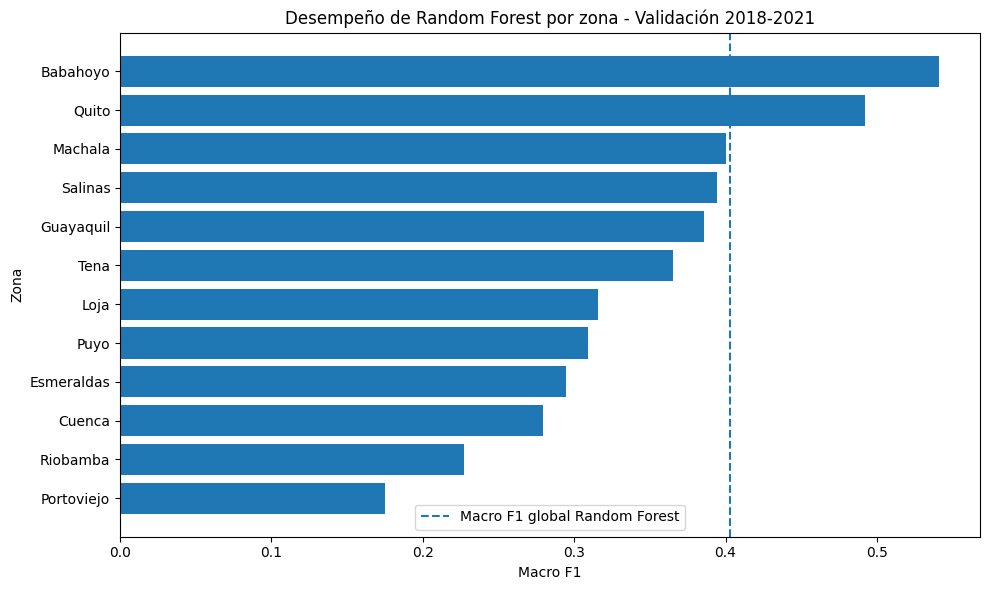

In [23]:
import matplotlib.pyplot as plt

plot_df = resultados_zona.sort_values("macro_f1")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["ciudad"],
    plot_df["macro_f1"]
)

plt.axvline(
    0.402850,
    linestyle="--",
    label="Macro F1 global Random Forest"
)

plt.xlabel("Macro F1")
plt.ylabel("Zona")
plt.title("Desempeño de Random Forest por zona - Validación 2018-2021")
plt.legend()

plt.tight_layout()
plt.show()